# 06. Анализ отдельных выпусков ОФЗ

Ноутбук соответствует второй странице дашборда: анализ цены, доходности/купонной ставки и объёма торгов по конкретному выпуску.


## 1. Импорт и загрузка данных


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SUMMARY_DIR = DATA_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

for path in [SUMMARY_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)


In [2]:
FIXED_PATH = PROCESSED_DIR / "fixed_datalens" / "ofz_fixed_with_key_rate_for_datalens.csv"
FLOATING_PATH = PROCESSED_DIR / "floating_datalens" / "ofz_floating_with_key_rate_for_datalens.csv"

parts = []
for path in [FIXED_PATH, FLOATING_PATH]:
    if path.exists():
        part = pd.read_csv(path)
        part["TRADEDATE"] = pd.to_datetime(part["TRADEDATE"], errors="coerce")
        parts.append(part)

if not parts:
    raise FileNotFoundError("Не найдены файлы fixed/floating с ключевой ставкой. Сначала запустите 04_prepare_datalens_datasets.ipynb")

df = pd.concat(parts, ignore_index=True, sort=False)

if "RATE_FOR_ANALYSIS" not in df.columns:
    df["RATE_FOR_ANALYSIS"] = df["YIELD_FOR_ANALYSIS"]
    if "FLOATING_COUPON_RATE_EST" in df.columns:
        df.loc[df["COUPON_TYPE"].eq("floating"), "RATE_FOR_ANALYSIS"] = df.loc[df["COUPON_TYPE"].eq("floating"), "FLOATING_COUPON_RATE_EST"]

bonds = df[["SECID", "SHORTNAME", "COUPON_TYPE"]].drop_duplicates().sort_values("SECID")
display(bonds)


,SECID,SHORTNAME,COUPON_TYPE
0,SU26207RMFS9,ОФЗ 26207,fixed
2516,SU26219RMFS4,ОФЗ 26219,fixed
4988,SU26226RMFS9,ОФЗ 26226,fixed
6805,SU26232RMFS7,ОФЗ 26232,fixed
8407,SU26236RMFS8,ОФЗ 26236,fixed
9771,SU26238RMFS4,ОФЗ 26238,fixed
10990,SU26240RMFS0,ОФЗ 26240,fixed
12193,SU26242RMFS6,ОФЗ 26242,fixed
13022,SU26243RMFS4,ОФЗ 26243,fixed
13751,SU29024RMFS5,ОФЗ 29024,floating


## 2. Выбор выпуска


In [3]:
# При необходимости вручную замените код выпуска на нужный.
SELECTED_SECID = df["SECID"].dropna().sort_values().iloc[0]

bond_df = (
    df[df["SECID"].eq(SELECTED_SECID)]
    .sort_values("TRADEDATE")
    .reset_index(drop=True)
)

print("Selected SECID:", SELECTED_SECID)
display(bond_df.head())


Selected SECID: SU26207RMFS9


,TRADEDATE,SECID,SHORTNAME,COUPON_TYPE,PLOT_GROUP,PRICE_FOR_ANALYSIS,YIELD_FOR_ANALYSIS,RATE_FOR_ANALYSIS,YEARS_TO_MATURITY,DURATION,VALUE,key_rate,YIELD_KEY_RATE_SPREAD,RATE_KEY_RATE_SPREAD,ACCINT,FLOATING_COUPON_RATE_EST,FLOATING_COUPON_KEY_RATE_SPREAD
0,2016-05-04,SU26207RMFS9,ОФЗ 26207,fixed,long,95.5773,8.99,8.99,10.751540,2610.0,7.549269e+08,11.0,-2.01,-2.01,NaN,NaN,NaN
1,2016-05-05,SU26207RMFS9,ОФЗ 26207,fixed,long,95.6335,8.98,8.98,10.748802,2610.0,1.133353e+08,11.0,-2.02,-2.02,NaN,NaN,NaN
2,2016-05-06,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7770,8.95,8.95,10.746064,2610.0,2.091805e+08,11.0,-2.05,-2.05,NaN,NaN,NaN
3,2016-05-10,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7496,8.96,8.96,10.735113,2606.0,2.660816e+07,11.0,-2.04,-2.04,NaN,NaN,NaN
4,2016-05-11,SU26207RMFS9,ОФЗ 26207,fixed,long,96.3739,8.86,8.86,10.732375,2610.0,5.351472e+08,11.0,-2.14,-2.14,NaN,NaN,NaN


## 3. Динамика цены


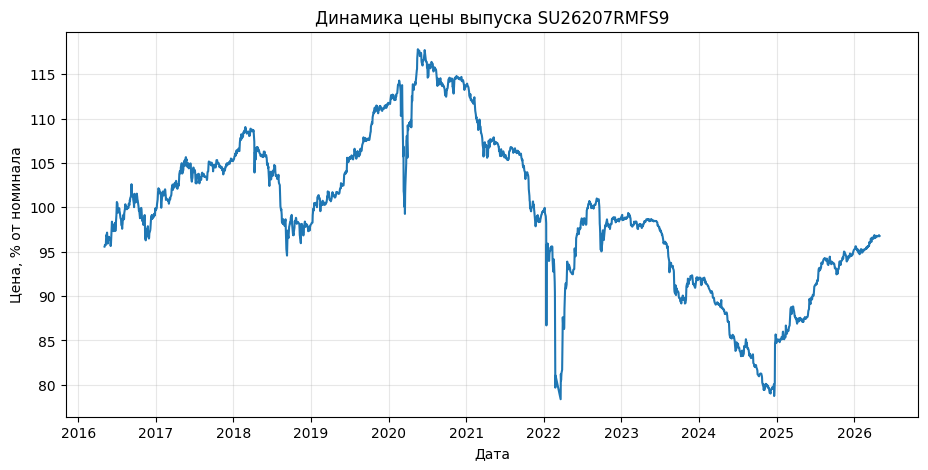

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_2_SU26207RMFS9_price.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bond_df["TRADEDATE"], bond_df["PRICE_FOR_ANALYSIS"])
ax.set_title(f"Динамика цены выпуска {SELECTED_SECID}")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, % от номинала")
ax.grid(True, alpha=0.3)

figure_path = FIGURES_DIR / f"page_2_{SELECTED_SECID}_price.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())


## 4. Динамика доходности/купонной ставки и ключевой ставки


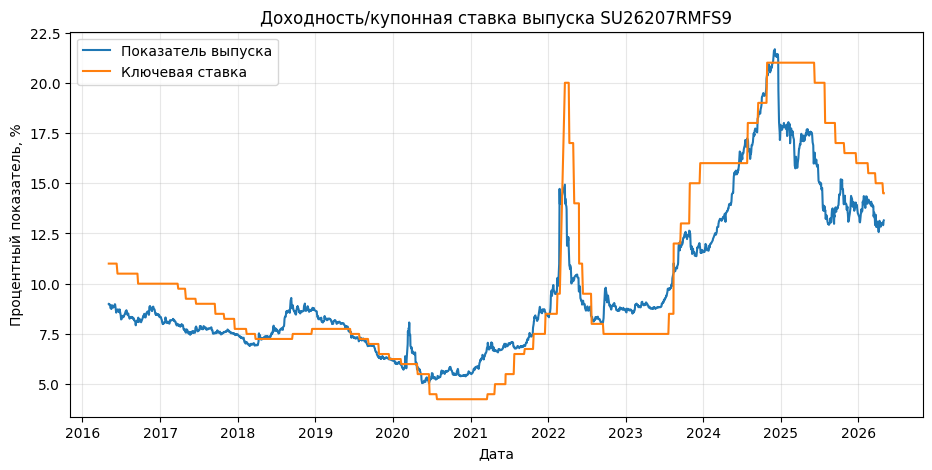

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_2_SU26207RMFS9_rate.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bond_df["TRADEDATE"], bond_df["RATE_FOR_ANALYSIS"], label="Показатель выпуска")

if "key_rate" in bond_df.columns:
    ax.plot(bond_df["TRADEDATE"], bond_df["key_rate"], label="Ключевая ставка")

ax.set_title(f"Доходность/купонная ставка выпуска {SELECTED_SECID}")
ax.set_xlabel("Дата")
ax.set_ylabel("Процентный показатель, %")
ax.grid(True, alpha=0.3)
ax.legend()

figure_path = FIGURES_DIR / f"page_2_{SELECTED_SECID}_rate.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())
